In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class State(TypedDict):
    text: str
    score: int
    iterations: int

In [3]:
def generate(state: State):
    print("Generating...")
    
    text = state["text"] + " improved"
    
    return {
        "text": text,
        "iterations": state["iterations"] + 1
    }

In [4]:
def evaluate(state: State):
    print("Evaluating...")
    
    # Example evaluation
    score = min(state["iterations"] * 3, 10)

    return {
        "score": score
    }

In [5]:
def should_continue(state: State):
    if state["score"] >= 10:
        return END

    if state["iterations"] >= 5:
        return END

    return "generate"


In [6]:
graph = StateGraph(State)

In [8]:

graph.add_node("generate", generate)
graph.add_node("evaluate", evaluate)


In [9]:
graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")

In [10]:
graph.add_conditional_edges(
    "evaluate",
    should_continue,
    {
        "generate": "generate",
        END: END
    }
)

In [11]:
app = graph.compile()

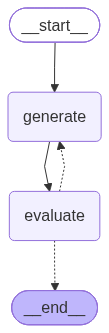

In [12]:
app

In [15]:
result = app.invoke({
    "text": "AI is useful",
    "score": 0,
    "iterations": 0
})

Generating...
Evaluating...
Generating...
Evaluating...
Generating...
Evaluating...
Generating...
Evaluating...


In [16]:
print(result)

{'text': 'AI is useful improved improved improved improved', 'score': 10, 'iterations': 4}
